In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## baseline spec for classifier

In [ ]:
df4 = pd.read_pickle('../data/df3_with_regions.pkl')

In [4]:
print(df4.columns.tolist())

['BUS_SVC_NUM', 'CRD_NUM', 'DEST_LOC_ID_NUM', 'ENTRY_DT', 'ENTRY_TM', 'EXIT_DT', 'EXIT_TM', 'JRNY_ID_NUM', 'ORIG_LOC_ID_NUM', 'RIDE_DISC_AMT', 'RIDE_DIST_KM_CNT', 'RIDE_FARE_AMT', 'RIDE_ID_NUM', 'RIDE_MIN_CNT', 'PATRON_CATG_ID_NUM', 'TRNSPT_MODE_CD', 'DEST_STATION_NAME', 'DEST_MRK_ID_NUM', 'DEST_LATITUDE', 'DEST_LONGITUDE', 'DEST_Travel_Type', 'ORIG_STATION_NAME', 'ORIG_MRK_ID_NUM', 'ORIG_LATITUDE', 'ORIG_LONGITUDE', 'ORIG_Travel_Type', 'next_orig_lat', 'next_orig_lon', 'next_orig_station', 'walk_distance', 'PATRON_CATG_DESC_TXT', 'walking_speed_ms', 'service_day', 'next_ENTRY_TM', 'next_ORIG_LOC_ID_NUM', 'next_BUS_SVC_NUM', 'next_TRNSPT_MODE_CD_x', 'is_last_stage', 'missing_info', 'same_bus_service', 'same_station_consecutive', 'return_or_intermediate', 'binary_flag', 'binary_flag_reason', 'binary_full_journey_seq', '(BINARY_Only)_journey_orig_station', '(BINARY_Only)_journey_entry_tm', '(BINARY_Only)_journey_dest_station', '(BINARY_Only)_journey_exit_tm', '(BINARY_Only)_journey_next_

- We compare each transfer window size against our rule-based classifier, which serves as the ground truth proxy for what constitutes a legitimate journey
- The comparison is done at the ride-pair level — each row represents a consecutive pair of rides by the same commuter
- Wrongly split: classifier says the pair is a transfer (same journey), but the window says the gap is too long and breaks them apart → commuter gets overcharged
- Wrongly merged: classifier says the pair is a new journey, but the window links them as a transfer → commuter incorrectly receives a transfer fare discount
- We vary the bus transfer window from 20 to 55 minutes in 5-minute increments, while holding train-to-train transfers fixed at 15 minutes
- For each window size, wrongly split and wrongly merged rates are computed separately for Adult, Student, and Senior Citizen
- As the window increases, wrongly split decreases (window becomes more permissive) and wrongly merged increases (window starts linking rides that should be separate)
- The goal is to identify the window size that best balances these two types of misclassification across patron groups

In [5]:
# how many ride pairs have missing time_gap_mins before filtering
total_before = len(df4[df4['is_last_stage'] == False])
missing_time_gap = df4[df4['is_last_stage'] == False]['time_gap_mins'].isna().sum()

print(f"Total ride pairs (excl last stage): {total_before:,}")
print(f"Missing time_gap_mins: {missing_time_gap:,}")
print(f"Missing %: {missing_time_gap / total_before * 100:.2f}%")

# how many unique card numbers affected
missing_crds = df4[
    (df4['is_last_stage'] == False) &
    (df4['time_gap_mins'].isna())
]['CRD_NUM'].nunique()
total_crds = df4['CRD_NUM'].nunique()

print(f"\nCard numbers with at least one missing pair: {missing_crds:,}")
print(f"Total card numbers: {total_crds:,}")
print(f"Affected card %: {missing_crds / total_crds * 100:.2f}%")

Total ride pairs (excl last stage): 5,211,360
Missing time_gap_mins: 241,123
Missing %: 4.63%

Card numbers with at least one missing pair: 28,144
Total card numbers: 2,453,068
Affected card %: 1.15%


In [6]:
# find card numbers with any missing time_gap_mins (excluding last stage)
crds_with_missing = df4[
    (df4['is_last_stage'] == False) &
    (df4['time_gap_mins'].isna())
]['CRD_NUM'].unique()

# filter once upfront — drop entire card number if any pair has missing data
df_pairs = df4[
    (df4['is_last_stage'] == False) &
    (~df4['CRD_NUM'].isin(crds_with_missing)) &     # remove card numbers with any missing pair
    (df4['PATRON_CATG_DESC_TXT'].notna())            # remove unknown patron category
].copy()

print(f"Card numbers removed: {len(crds_with_missing):,}")
print(f"Total ride pairs remaining: {len(df_pairs):,}")
print(df_pairs['mode_pair'].value_counts())

Card numbers removed: 28,144
Total ride pairs remaining: 4,753,028
mode_pair
bus_bus        1703677
train_train    1187501
train_bus       931019
bus_train       930831
Name: count, dtype: int64


In [7]:
# ── Cell 2: window comparison loop ───────────────────────────────────────────

results = []

# classifier verdict is fixed across all windows
classifier_says_transfer = (df_pairs['BTS_flag'] == False)

for w in range(20, 60, 5):

    window = df_pairs['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (
        ~df_pairs['same_bus_service'] &
        ~df_pairs['same_station_consecutive'] &
        (df_pairs['time_gap_mins'] <= window)
    )

    wrongly_split  = classifier_says_transfer & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer & window_says_transfer

    results.append({
        'window_mins':             w,
        'patron':                  'Overall',
        'wrongly_split_n':         wrongly_split.sum(),
        'wrongly_merged_n':        wrongly_merged.sum(),
        'wrongly_split_pct':       wrongly_split.mean() * 100,
        'wrongly_merged_pct':      wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':  (wrongly_split[classifier_says_transfer].mean() * 100) if classifier_says_transfer.sum() > 0 else 0,
        'wrongly_merged_cond_pct': (wrongly_merged[~classifier_says_transfer].mean() * 100) if (~classifier_says_transfer).sum() > 0 else 0,
    })

    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        results.append({
            'window_mins':             w,
            'patron':                  patron,
            'wrongly_split_n':         wrongly_split_mask.sum(),
            'wrongly_merged_n':        wrongly_merged_mask.sum(),
            'wrongly_split_pct':       wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':      wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':  (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct': (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_df = pd.DataFrame(results)
print(results_df)

    window_mins          patron  wrongly_split_n  wrongly_merged_n  \
0            20         Overall           320219            114578   
1            20         Student            38145             11806   
2            20           Adult           184343             82132   
3            20  Senior Citizen            97731             20640   
4            25         Overall           314992            166199   
5            25         Student            37885             16083   
6            25           Adult           181555            116853   
7            25  Senior Citizen            95552             33263   
8            30         Overall           314017            209025   
9            30         Student            37853             19356   
10           30           Adult           181129            144134   
11           30  Senior Citizen            95035             45535   
12           35         Overall           313830            245444   
13           35     

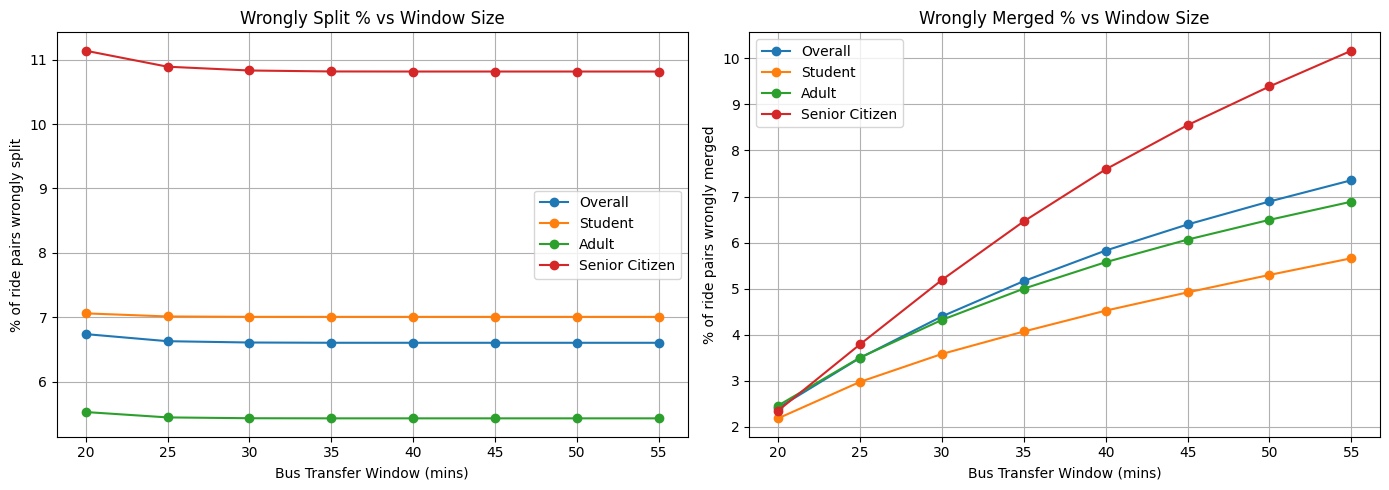

In [8]:
# ── Cell 3: visualise ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron in results_df['patron'].unique():
    sub = results_df[results_df['patron'] == patron].sort_values('window_mins')
    axes[0].plot(sub['window_mins'], sub['wrongly_split_pct'],  marker='o', label=patron)
    axes[1].plot(sub['window_mins'], sub['wrongly_merged_pct'], marker='o', label=patron)

axes[0].set_title('Wrongly Split % vs Window Size')
axes[0].set_xlabel('Bus Transfer Window (mins)')
axes[0].set_ylabel('% of ride pairs wrongly split')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Wrongly Merged % vs Window Size')
axes[1].set_xlabel('Bus Transfer Window (mins)')
axes[1].set_ylabel('% of ride pairs wrongly merged')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [9]:
# classifier verdict is fixed across all windows
classifier_says_transfer = (df_pairs['BTS_flag'] == False)

baseline_results = []

for w in range(20, 60, 5):

    window = df_pairs['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (
        ~df_pairs['same_bus_service'] &
        ~df_pairs['same_station_consecutive'] &
        (df_pairs['time_gap_mins'] <= window)
    )

    wrongly_split  = classifier_says_transfer & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer & window_says_transfer

    baseline_results.append({
        'spec':                     'baseline',
        'window_mins':              w,
        'patron':                   'Overall',
        'classifier_transfer_n':    classifier_says_transfer.sum(),
        'classifier_new_journey_n': (~classifier_says_transfer).sum(),
        'window_transfer_n':        window_says_transfer.sum(),
        'window_new_journey_n':     (~window_says_transfer).sum(),
        'wrongly_split_n':          wrongly_split.sum(),
        'wrongly_merged_n':         wrongly_merged.sum(),
        'wrongly_split_pct':        wrongly_split.mean() * 100,
        'wrongly_merged_pct':       wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':   (wrongly_split[classifier_says_transfer].mean() * 100) if classifier_says_transfer.sum() > 0 else 0,
        'wrongly_merged_cond_pct':  (wrongly_merged[~classifier_says_transfer].mean() * 100) if (~classifier_says_transfer).sum() > 0 else 0,
    })

    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        baseline_results.append({
            'spec':                     'baseline',
            'window_mins':              w,
            'patron':                   patron,
            'classifier_transfer_n':    clf_transfer_mask.sum(),
            'classifier_new_journey_n': (~clf_transfer_mask).sum(),
            'window_transfer_n':        window_says_transfer[mask].sum(),
            'window_new_journey_n':     (~window_says_transfer[mask]).sum(),
            'wrongly_split_n':          wrongly_split_mask.sum(),
            'wrongly_merged_n':         wrongly_merged_mask.sum(),
            'wrongly_split_pct':        wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':       wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':   (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct':  (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_baseline_df = pd.DataFrame(baseline_results)
print(results_baseline_df.to_string())

        spec  window_mins          patron  classifier_transfer_n  classifier_new_journey_n  window_transfer_n  window_new_journey_n  wrongly_split_n  wrongly_merged_n  wrongly_split_pct  wrongly_merged_pct  wrongly_split_cond_pct  wrongly_merged_cond_pct
0   baseline           20         Overall                1874130                   2878898            1668489               3084539           320219            114578           6.737158            2.410632               17.086275                 3.979926
1   baseline           20         Student                 223493                    316859             197154                343198            38145             11806           7.059287            2.184872               17.067649                 3.725948
2   baseline           20           Adult                1303469                   2031766            1201258               2133977           184343             82132           5.527137            2.462555               14.142492      

In [10]:
# ── Regional welfare table — baseline ────────────────────────────────────────
regional_baseline_results = []

classifier_says_transfer = (df_pairs['BTS_flag'] == False)

for w in range(20, 60, 5):

    window = df_pairs['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )
    window_says_transfer = (
        ~df_pairs['same_bus_service'] &
        ~df_pairs['same_station_consecutive'] &
        (df_pairs['time_gap_mins'] <= window)
    )

    wrongly_split  = classifier_says_transfer & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer & window_says_transfer

    for region_type, region_col in [('house_area', 'house_area'), ('orig_region', 'orig_region')]:
        for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
            patron_mask = df_pairs['PATRON_CATG_DESC_TXT'] == patron
            for region_val in df_pairs.loc[patron_mask, region_col].dropna().unique():
                mask = patron_mask & (df_pairs[region_col] == region_val)
                wrongly_split_mask  = wrongly_split[mask]
                wrongly_merged_mask = wrongly_merged[mask]

                regional_baseline_results.append({
                    'spec':               'baseline',
                    'window_mins':        w,
                    'patron':             patron,
                    'region_type':        region_type,
                    'region_value':       region_val,
                    'wrongly_split_n':    wrongly_split_mask.sum(),
                    'wrongly_merged_n':   wrongly_merged_mask.sum(),
                    'wrongly_split_pct':  wrongly_split_mask.mean() * 100,
                    'wrongly_merged_pct': wrongly_merged_mask.mean() * 100,
                })

regional_baseline_df = pd.DataFrame(regional_baseline_results)
print(f"Baseline regional rows: {len(regional_baseline_df):,}")

KeyboardInterrupt: 

In [ ]:
# ── Marginal welfare table — baseline ────────────────────────────────────────
# for each window step w → w+5, find pairs newly linked by the larger window
# marginal benefit = newly linked where classifier says transfer (legitimate rescue)
# marginal cost    = newly linked where classifier says new journey (illegitimate link)

marginal_baseline_results = []
windows = list(range(20, 60, 5))

for i in range(len(windows) - 1):
    w_from = windows[i]
    w_to   = windows[i + 1]

    window_from = df_pairs['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_from)
    window_to   = df_pairs['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_to)

    linked_by_from = (
        ~df_pairs['same_bus_service'] &
        ~df_pairs['same_station_consecutive'] &
        (df_pairs['time_gap_mins'] <= window_from)
    )
    linked_by_to = (
        ~df_pairs['same_bus_service'] &
        ~df_pairs['same_station_consecutive'] &
        (df_pairs['time_gap_mins'] <= window_to)
    )
    newly_linked   = linked_by_to & ~linked_by_from

    marginal_benefit = newly_linked & classifier_says_transfer
    marginal_cost    = newly_linked & ~classifier_says_transfer

    marginal_baseline_results.append({
        'spec':               'baseline',
        'window_from':        w_from,
        'window_to':          w_to,
        'patron':             'Overall',
        'newly_linked_n':     newly_linked.sum(),
        'marginal_benefit_n': marginal_benefit.sum(),
        'marginal_cost_n':    marginal_cost.sum(),
    })

    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs['PATRON_CATG_DESC_TXT'] == patron
        marginal_baseline_results.append({
            'spec':               'baseline',
            'window_from':        w_from,
            'window_to':          w_to,
            'patron':             patron,
            'newly_linked_n':     newly_linked[mask].sum(),
            'marginal_benefit_n': marginal_benefit[mask].sum(),
            'marginal_cost_n':    marginal_cost[mask].sum(),
        })

marginal_baseline_df = pd.DataFrame(marginal_baseline_results)
print(marginal_baseline_df.to_string())

In [ ]:
# free baseline df4 from memory before loading next spec
del df4, df_pairs
import gc
gc.collect()


## strict spec for classifier

In [ ]:
# load strict classifier
df4_strict = pd.read_pickle('../data/df3_strict_with_regions.pkl')

In [ ]:
# find card numbers with any missing time_gap_mins
crds_with_missing_strict = df4_strict[
    (df4_strict['is_last_stage'] == False) &
    (df4_strict['time_gap_mins'].isna())
]['CRD_NUM'].unique()

# filter to valid ride pairs
df_pairs_strict = df4_strict[
    (df4_strict['is_last_stage'] == False) &
    (~df4_strict['CRD_NUM'].isin(crds_with_missing_strict)) &
    (df4_strict['PATRON_CATG_DESC_TXT'].notna())
].copy()

print(f"Strict — total ride pairs: {len(df_pairs_strict):,}")
print(df_pairs_strict['mode_pair'].value_counts())

In [ ]:
classifier_says_transfer_strict = (df_pairs_strict['BTS_flag'] == False)

strict_results = []

for w in range(20, 60, 5):

    window = df_pairs_strict['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (
        ~df_pairs_strict['same_bus_service'] &
        ~df_pairs_strict['same_station_consecutive'] &
        (df_pairs_strict['time_gap_mins'] <= window)
    )

    wrongly_split  = classifier_says_transfer_strict & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer_strict & window_says_transfer

    strict_results.append({
        'spec':                     'strict',
        'window_mins':              w,
        'patron':                   'Overall',
        'classifier_transfer_n':    classifier_says_transfer_strict.sum(),
        'classifier_new_journey_n': (~classifier_says_transfer_strict).sum(),
        'window_transfer_n':        window_says_transfer.sum(),
        'window_new_journey_n':     (~window_says_transfer).sum(),
        'wrongly_split_n':          wrongly_split.sum(),
        'wrongly_merged_n':         wrongly_merged.sum(),
        'wrongly_split_pct':        wrongly_split.mean() * 100,
        'wrongly_merged_pct':       wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':   (wrongly_split[classifier_says_transfer_strict].mean() * 100) if classifier_says_transfer_strict.sum() > 0 else 0,
        'wrongly_merged_cond_pct':  (wrongly_merged[~classifier_says_transfer_strict].mean() * 100) if (~classifier_says_transfer_strict).sum() > 0 else 0,
    })

    for patron in df_pairs_strict['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs_strict['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer_strict[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        strict_results.append({
            'spec':                     'strict',
            'window_mins':              w,
            'patron':                   patron,
            'classifier_transfer_n':    clf_transfer_mask.sum(),
            'classifier_new_journey_n': (~clf_transfer_mask).sum(),
            'window_transfer_n':        window_says_transfer[mask].sum(),
            'window_new_journey_n':     (~window_says_transfer[mask]).sum(),
            'wrongly_split_n':          wrongly_split_mask.sum(),
            'wrongly_merged_n':         wrongly_merged_mask.sum(),
            'wrongly_split_pct':        wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':       wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':   (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct':  (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_strict_df = pd.DataFrame(strict_results)
print(results_strict_df.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron in results_strict_df['patron'].unique():
    sub = results_strict_df[results_strict_df['patron'] == patron].sort_values('window_mins')
    axes[0].plot(sub['window_mins'], sub['wrongly_split_pct'],  marker='o', label=patron)
    axes[1].plot(sub['window_mins'], sub['wrongly_merged_pct'], marker='o', label=patron)

axes[0].set_title('Strict — Wrongly Split % vs Window Size')
axes[0].set_xlabel('Bus Transfer Window (mins)')
axes[0].set_ylabel('% of ride pairs wrongly split')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Strict — Wrongly Merged % vs Window Size')
axes[1].set_xlabel('Bus Transfer Window (mins)')
axes[1].set_ylabel('% of ride pairs wrongly merged')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ── Regional welfare table — strict ──────────────────────────────────────────
regional_strict_results = []

for w in range(20, 60, 5):

    window = df_pairs_strict['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )
    window_says_transfer = (
        ~df_pairs_strict['same_bus_service'] &
        ~df_pairs_strict['same_station_consecutive'] &
        (df_pairs_strict['time_gap_mins'] <= window)
    )

    wrongly_split  = classifier_says_transfer_strict & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer_strict & window_says_transfer

    for region_type, region_col in [('house_area', 'house_area'), ('orig_region', 'orig_region')]:
        for patron in df_pairs_strict['PATRON_CATG_DESC_TXT'].unique():
            patron_mask = df_pairs_strict['PATRON_CATG_DESC_TXT'] == patron
            for region_val in df_pairs_strict.loc[patron_mask, region_col].dropna().unique():
                mask = patron_mask & (df_pairs_strict[region_col] == region_val)
                wrongly_split_mask  = wrongly_split[mask]
                wrongly_merged_mask = wrongly_merged[mask]

                regional_strict_results.append({
                    'spec':               'strict',
                    'window_mins':        w,
                    'patron':             patron,
                    'region_type':        region_type,
                    'region_value':       region_val,
                    'wrongly_split_n':    wrongly_split_mask.sum(),
                    'wrongly_merged_n':   wrongly_merged_mask.sum(),
                    'wrongly_split_pct':  wrongly_split_mask.mean() * 100,
                    'wrongly_merged_pct': wrongly_merged_mask.mean() * 100,
                })

regional_strict_df = pd.DataFrame(regional_strict_results)
print(f"Strict regional rows: {len(regional_strict_df):,}")

In [ ]:
# ── Marginal welfare table — strict ──────────────────────────────────────────

marginal_strict_results = []

for i in range(len(windows) - 1):
    w_from = windows[i]
    w_to   = windows[i + 1]

    window_from = df_pairs_strict['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_from)
    window_to   = df_pairs_strict['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_to)

    linked_by_from = (
        ~df_pairs_strict['same_bus_service'] &
        ~df_pairs_strict['same_station_consecutive'] &
        (df_pairs_strict['time_gap_mins'] <= window_from)
    )
    linked_by_to = (
        ~df_pairs_strict['same_bus_service'] &
        ~df_pairs_strict['same_station_consecutive'] &
        (df_pairs_strict['time_gap_mins'] <= window_to)
    )
    newly_linked   = linked_by_to & ~linked_by_from

    marginal_benefit = newly_linked & classifier_says_transfer_strict
    marginal_cost    = newly_linked & ~classifier_says_transfer_strict

    marginal_strict_results.append({
        'spec':               'strict',
        'window_from':        w_from,
        'window_to':          w_to,
        'patron':             'Overall',
        'newly_linked_n':     newly_linked.sum(),
        'marginal_benefit_n': marginal_benefit.sum(),
        'marginal_cost_n':    marginal_cost.sum(),
    })

    for patron in df_pairs_strict['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs_strict['PATRON_CATG_DESC_TXT'] == patron
        marginal_strict_results.append({
            'spec':               'strict',
            'window_from':        w_from,
            'window_to':          w_to,
            'patron':             patron,
            'newly_linked_n':     newly_linked[mask].sum(),
            'marginal_benefit_n': marginal_benefit[mask].sum(),
            'marginal_cost_n':    marginal_cost[mask].sum(),
        })

marginal_strict_df = pd.DataFrame(marginal_strict_results)
print(marginal_strict_df.to_string())

## lenient spec for classifier

In [ ]:
del df4_strict, df_pairs_strict
gc.collect()

In [ ]:
df4_lenient = pd.read_pickle('../data/df3_lenient_with_regions.pkl')

In [ ]:
crds_with_missing_lenient = df4_lenient[
    (df4_lenient['is_last_stage'] == False) &
    (df4_lenient['time_gap_mins'].isna())
]['CRD_NUM'].unique()

df_pairs_lenient = df4_lenient[
    (df4_lenient['is_last_stage'] == False) &
    (~df4_lenient['CRD_NUM'].isin(crds_with_missing_lenient)) &
    (df4_lenient['PATRON_CATG_DESC_TXT'].notna())
].copy()

print(f"Lenient — total ride pairs: {len(df_pairs_lenient):,}")
print(df_pairs_lenient['mode_pair'].value_counts())

In [ ]:
classifier_says_transfer_lenient = (df_pairs_lenient['BTS_flag'] == False)

lenient_results = []

for w in range(20, 60, 5):

    window = df_pairs_lenient['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (
        ~df_pairs_lenient['same_bus_service'] &
        ~df_pairs_lenient['same_station_consecutive'] &
        (df_pairs_lenient['time_gap_mins'] <= window)
    )

    wrongly_split  = classifier_says_transfer_lenient & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer_lenient & window_says_transfer

    lenient_results.append({
        'spec':                     'lenient',
        'window_mins':              w,
        'patron':                   'Overall',
        'classifier_transfer_n':    classifier_says_transfer_lenient.sum(),
        'classifier_new_journey_n': (~classifier_says_transfer_lenient).sum(),
        'window_transfer_n':        window_says_transfer.sum(),
        'window_new_journey_n':     (~window_says_transfer).sum(),
        'wrongly_split_n':          wrongly_split.sum(),
        'wrongly_merged_n':         wrongly_merged.sum(),
        'wrongly_split_pct':        wrongly_split.mean() * 100,
        'wrongly_merged_pct':       wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':   (wrongly_split[classifier_says_transfer_lenient].mean() * 100) if classifier_says_transfer_lenient.sum() > 0 else 0,
        'wrongly_merged_cond_pct':  (wrongly_merged[~classifier_says_transfer_lenient].mean() * 100) if (~classifier_says_transfer_lenient).sum() > 0 else 0,
    })

    for patron in df_pairs_lenient['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs_lenient['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer_lenient[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        lenient_results.append({
            'spec':                     'lenient',
            'window_mins':              w,
            'patron':                   patron,
            'classifier_transfer_n':    clf_transfer_mask.sum(),
            'classifier_new_journey_n': (~clf_transfer_mask).sum(),
            'window_transfer_n':        window_says_transfer[mask].sum(),
            'window_new_journey_n':     (~window_says_transfer[mask]).sum(),
            'wrongly_split_n':          wrongly_split_mask.sum(),
            'wrongly_merged_n':         wrongly_merged_mask.sum(),
            'wrongly_split_pct':        wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':       wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':   (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct':  (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_lenient_df = pd.DataFrame(lenient_results)
print(results_lenient_df.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron in results_lenient_df['patron'].unique():
    sub = results_lenient_df[results_lenient_df['patron'] == patron].sort_values('window_mins')
    axes[0].plot(sub['window_mins'], sub['wrongly_split_pct'],  marker='o', label=patron)
    axes[1].plot(sub['window_mins'], sub['wrongly_merged_pct'], marker='o', label=patron)

axes[0].set_title('Lenient — Wrongly Split % vs Window Size')
axes[0].set_xlabel('Bus Transfer Window (mins)')
axes[0].set_ylabel('% of ride pairs wrongly split')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Lenient — Wrongly Merged % vs Window Size')
axes[1].set_xlabel('Bus Transfer Window (mins)')
axes[1].set_ylabel('% of ride pairs wrongly merged')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ── Regional welfare table — lenient ─────────────────────────────────────────
regional_lenient_results = []

for w in range(20, 60, 5):

    window = df_pairs_lenient['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )
    window_says_transfer = (
        ~df_pairs_lenient['same_bus_service'] &
        ~df_pairs_lenient['same_station_consecutive'] &
        (df_pairs_lenient['time_gap_mins'] <= window)
    )

    wrongly_split  = classifier_says_transfer_lenient & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer_lenient & window_says_transfer

    for region_type, region_col in [('house_area', 'house_area'), ('orig_region', 'orig_region')]:
        for patron in df_pairs_lenient['PATRON_CATG_DESC_TXT'].unique():
            patron_mask = df_pairs_lenient['PATRON_CATG_DESC_TXT'] == patron
            for region_val in df_pairs_lenient.loc[patron_mask, region_col].dropna().unique():
                mask = patron_mask & (df_pairs_lenient[region_col] == region_val)
                wrongly_split_mask  = wrongly_split[mask]
                wrongly_merged_mask = wrongly_merged[mask]

                regional_lenient_results.append({
                    'spec':               'lenient',
                    'window_mins':        w,
                    'patron':             patron,
                    'region_type':        region_type,
                    'region_value':       region_val,
                    'wrongly_split_n':    wrongly_split_mask.sum(),
                    'wrongly_merged_n':   wrongly_merged_mask.sum(),
                    'wrongly_split_pct':  wrongly_split_mask.mean() * 100,
                    'wrongly_merged_pct': wrongly_merged_mask.mean() * 100,
                })

regional_lenient_df = pd.DataFrame(regional_lenient_results)
print(f"Lenient regional rows: {len(regional_lenient_df):,}")

In [ ]:
# ── Marginal welfare table — lenient ─────────────────────────────────────────

marginal_lenient_results = []

for i in range(len(windows) - 1):
    w_from = windows[i]
    w_to   = windows[i + 1]

    window_from = df_pairs_lenient['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_from)
    window_to   = df_pairs_lenient['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_to)

    linked_by_from = (
        ~df_pairs_lenient['same_bus_service'] &
        ~df_pairs_lenient['same_station_consecutive'] &
        (df_pairs_lenient['time_gap_mins'] <= window_from)
    )
    linked_by_to = (
        ~df_pairs_lenient['same_bus_service'] &
        ~df_pairs_lenient['same_station_consecutive'] &
        (df_pairs_lenient['time_gap_mins'] <= window_to)
    )
    newly_linked   = linked_by_to & ~linked_by_from

    marginal_benefit = newly_linked & classifier_says_transfer_lenient
    marginal_cost    = newly_linked & ~classifier_says_transfer_lenient

    marginal_lenient_results.append({
        'spec':               'lenient',
        'window_from':        w_from,
        'window_to':          w_to,
        'patron':             'Overall',
        'newly_linked_n':     newly_linked.sum(),
        'marginal_benefit_n': marginal_benefit.sum(),
        'marginal_cost_n':    marginal_cost.sum(),
    })

    for patron in df_pairs_lenient['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs_lenient['PATRON_CATG_DESC_TXT'] == patron
        marginal_lenient_results.append({
            'spec':               'lenient',
            'window_from':        w_from,
            'window_to':          w_to,
            'patron':             patron,
            'newly_linked_n':     newly_linked[mask].sum(),
            'marginal_benefit_n': marginal_benefit[mask].sum(),
            'marginal_cost_n':    marginal_cost[mask].sum(),
        })

marginal_lenient_df = pd.DataFrame(marginal_lenient_results)
print(marginal_lenient_df.to_string())

In [ ]:
del df4_lenient, df_pairs_lenient
gc.collect()

## Combining all results

In [ ]:
# combine all 3 specs into one df
final_results_df = pd.concat(
    [results_baseline_df, results_strict_df, results_lenient_df],
    ignore_index=True
)

final_results_df.to_csv('../data/welfare_results.csv', index=False)
print('Saved welfare_results.csv')
print(final_results_df.shape)

In [ ]:
# combine regional results across all specs
regional_results_df = pd.concat(
    [regional_baseline_df, regional_strict_df, regional_lenient_df],
    ignore_index=True
)

regional_results_df.to_csv('../data/welfare_results_regional.csv', index=False)
print('Saved welfare_results_regional.csv')
print(regional_results_df.shape)

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

patrons = ['Overall', 'Adult', 'Student', 'Senior Citizen']
specs = ['strict', 'baseline', 'lenient']
colors = {'strict': 'red', 'baseline': 'blue', 'lenient': 'green'}

patrons_to_plot = ['Overall', 'Adult', 'Student', 'Senior Citizen']

for col, patron in enumerate(['Overall', 'Adult', 'Student', 'Senior Citizen']):
    for spec in specs:
        # get the right df
        df_spec = {
            'strict': results_strict_df,
            'baseline': results_baseline_df,
            'lenient': results_lenient_df
        }[spec]

        sub = df_spec[df_spec['patron'] == patron].sort_values('window_mins')

        # wrongly split — top row
        axes[0, col].plot(
            sub['window_mins'], sub['wrongly_split_pct'],
            marker='o', label=spec, color=colors[spec]
        )
        # wrongly merged — bottom row
        axes[1, col].plot(
            sub['window_mins'], sub['wrongly_merged_pct'],
            marker='o', label=spec, color=colors[spec]
        )

    axes[0, col].set_title(f'Wrongly Split % — {patron}')
    axes[0, col].set_xlabel('Bus Transfer Window (mins)')
    axes[0, col].set_ylabel('% wrongly split')
    axes[0, col].legend()
    axes[0, col].grid(True)

    axes[1, col].set_title(f'Wrongly Merged % — {patron}')
    axes[1, col].set_xlabel('Bus Transfer Window (mins)')
    axes[1, col].set_ylabel('% wrongly merged')
    axes[1, col].legend()
    axes[1, col].grid(True)

plt.suptitle('Welfare Analysis — All Specs vs Transfer Window', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Function for welfare analysis


In [ ]:
def get_welfare_summary(patron, window, spec):
    """
    Look up welfare results for a given patron category, transfer window, and classifier spec.

    Inputs:
    - patron: 'Overall', 'Adult', 'Student', 'Senior Citizen'
    - window: integer, one of 20, 25, 30, 35, 40, 45, 50, 55
    - spec: 'strict', 'baseline', 'lenient'

    Returns:
    - dict with split/merge error counts, unconditional rates, and conditional rates
    """
    row = final_results_df[
        (final_results_df['patron'] == patron) &
        (final_results_df['window_mins'] == window) &
        (final_results_df['spec'] == spec)
    ]

    if row.empty:
        return f"No data found for patron='{patron}', window={window}, spec='{spec}'"

    row = row.iloc[0]

    return {
        'spec':                     spec,
        'patron':                   patron,
        'window_mins':              window,
        'classifier_transfer_n':    row['classifier_transfer_n'],
        'classifier_new_journey_n': row['classifier_new_journey_n'],
        'window_transfer_n':        row['window_transfer_n'],
        'window_new_journey_n':     row['window_new_journey_n'],
        # split error: window too strict, breaks classifier-valid transfers → commuter overcharged
        'split_error_n':            row['wrongly_split_n'],
        'split_error_pct':          row['wrongly_split_pct'],          # % of all pairs
        'split_error_cond_pct':     row['wrongly_split_cond_pct'],     # % of classifier-said transfers
        # merge error: window too lenient, links classifier-separate journeys → fare undercharged
        'merge_error_n':            row['wrongly_merged_n'],
        'merge_error_pct':          row['wrongly_merged_pct'],         # % of all pairs
        'merge_error_cond_pct':     row['wrongly_merged_cond_pct'],    # % of classifier-said new journeys
    }

In [ ]:
# example usage
print(get_welfare_summary('Adult', 35, 'baseline'))

In [ ]:
# combine marginal results across all specs
marginal_df = pd.concat(
    [marginal_baseline_df, marginal_strict_df, marginal_lenient_df],
    ignore_index=True
)

marginal_df.to_csv('../data/welfare_marginal.csv', index=False)
print('Saved welfare_marginal.csv')
print(marginal_df.to_string())

In [ ]:
def get_marginal_summary(patron, spec, window_from):
    """
    Look up the marginal welfare effect of increasing the transfer window by 5 minutes.

    Inputs:
    - patron: 'Overall', 'Adult', 'Student', 'Senior Citizen'
    - spec: 'strict', 'baseline', 'lenient'
    - window_from: integer, one of 20, 25, 30, 35, 40, 45, 50
                   (returns the effect of moving from window_from to window_from + 5)

    Returns:
    - dict with newly linked pairs, marginal benefit (legitimate transfers rescued),
      and marginal cost (illegitimate links added)
    """
    window_to = window_from + 5

    row = marginal_df[
        (marginal_df['patron'] == patron) &
        (marginal_df['spec'] == spec) &
        (marginal_df['window_from'] == window_from) &
        (marginal_df['window_to'] == window_to)
    ]

    if row.empty:
        return f"No data found for patron='{patron}', spec='{spec}', window_from={window_from}"

    row = row.iloc[0]

    return {
        'spec':               spec,
        'patron':             patron,
        'window_from':        window_from,
        'window_to':          window_to,
        'newly_linked_n':     row['newly_linked_n'],       # total pairs newly linked by the larger window
        'marginal_benefit_n': row['marginal_benefit_n'],   # newly linked where classifier says transfer → legitimate rescue
        'marginal_cost_n':    row['marginal_cost_n'],      # newly linked where classifier says new journey → illegitimate link
    }

# example usage
print(get_marginal_summary('Adult', 'baseline', 35))